# **Optimización TP1**: Perfil de Desempeño

In [ ]:
using Pkg
Pkg.add(["DataFrames", "LinearAlgebra", "Plots"])

In [1]:
include("benchmarks.jl")
using LinearAlgebra, Plots, DataFrames

LoadError: SystemError: opening file "/notebooks/benchmarks.jl": No such file or directory

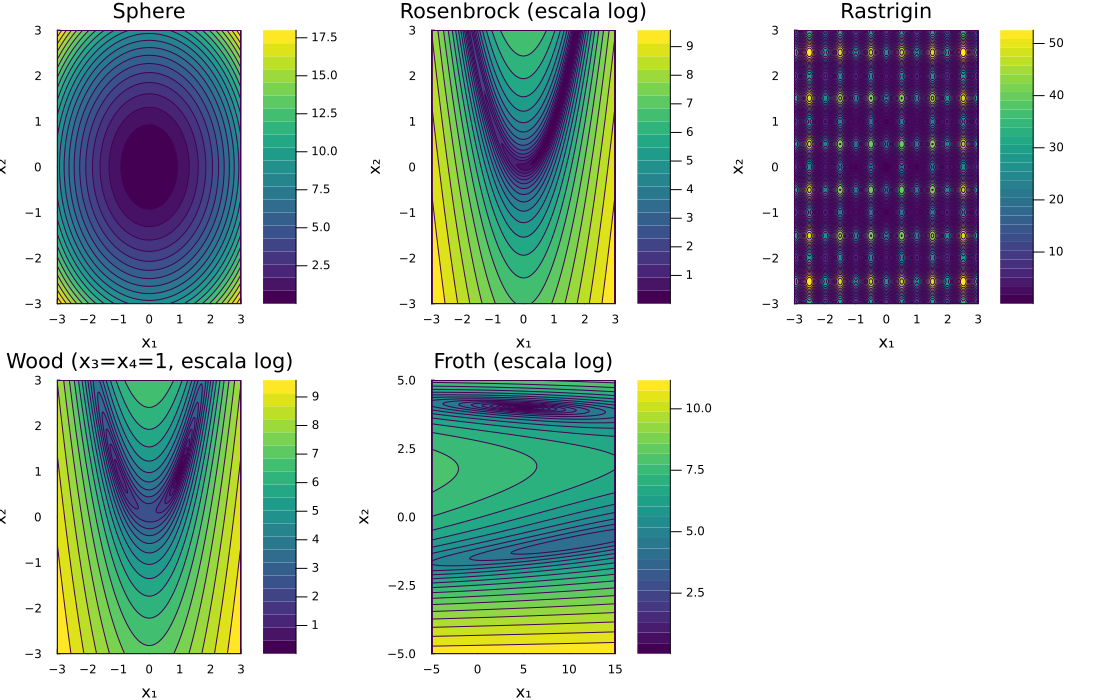

In [29]:
# ── Sphere ────────────────────────────────────────────────────────────────────
p1 = contourf(x_range, y_range, Z(sphere),
    levels=20, color=:viridis, title="Sphere",
    xlabel="x₁", ylabel="x₂")

# ── Rosenbrock ────────────────────────────────────────────────────────────────
p2 = contourf(x_range, y_range, log1p.(Z(rosenbrock)),
    levels=20, color=:viridis, title="Rosenbrock (escala log)",
    xlabel="x₁", ylabel="x₂")

# ── Rastrigin ────────────────────────────────────────────────────────────────
p3 = contourf(x_range, y_range, Z(rastrigin),
    levels=30, color=:viridis, title="Rastrigin",
    xlabel="x₁", ylabel="x₂")

# ── Wood ─────────────────────────────────────────────────────────────────────
wood_2d(x) = wood([x[1], x[2], 1.0, 1.0])
p4 = contourf(x_range, y_range, log1p.(Z(wood_2d)),
    levels=20, color=:viridis, title="Wood (x₃=x₄=1, escala log)",
    xlabel="x₁", ylabel="x₂")

# ── Froth ─────────────────────────────────────────────────────────────────────
x_fr = range(-5, 15, length=200)
y_fr = range(-5, 5,  length=200)
Z_fr = [froth([x, y]) for y in y_fr, x in x_fr]
p5 = contourf(x_fr, y_fr, log1p.(Z_fr),
    levels=25, color=:viridis, title="Froth (escala log)",
    xlabel="x₁", ylabel="x₂")

# ── Layout ────────────────────────────────────────────────────────────────────
plot(p1, p2, p3, p4, p5,
    layout=(2, 3),
    size=(1100, 700),
    legend=false)

## **Ejercicios**: Análisis de desempeño

### **Ejercicio 5**: Métodos de descenso

In [30]:
function gradiente_constante(x₀, f, ∇f, η=0.0001, max_iter=10000)
    # Condiciones iniciales
    xk = x₀; gk = ∇f(xk); dk = -gk
    iter = 0
    status = "NO_CONVERGIO"

    # Iteraciones
    while iter < max_iter
        # Criterio de parada
        if norm(gk) < 1e-8
            status = "CONVERGIO"
            break

        end
        # Actualización
        xk = (xk + η .* dk); gk = ∇f(xk); dk = -gk
        iter += 1
        
    end
    return status, iter, norm(gk), xk
    
end

gradiente_constante (generic function with 3 methods)

In [31]:
function armijo(a₀, xk, dk, f, ∇f)
    # Busqueda lineal
    h(a) = f(xk + a .* dk)
    dh₀  = ∇f(xk)' * dk

    # Itero para buscar ak
    ak = a₀; iter = true
    while iter
        # Paso muy largo
        if (h(ak) > h(0) + dh₀*ak/2)
            ak = ak/2
        # Paso muy corto
        elseif (h(2*ak) <= h(0) + dh₀*ak) 
            ak = 10*ak
        # Cumple Armijo
        else                               
            return ak
            
        end
    end
end

armijo (generic function with 1 method)

In [32]:
function gradiente_armijo(x₀, f, ∇f, max_iter=10000)
    # Condiciones iniciales
    xk = x₀; gk = ∇f(xk); ak = 1/2; dk = -gk
    iter = 0
    status = "NO_CONVERGIO"

    # Iteraciones
    while iter < max_iter
        # Criterio de parada
        if norm(gk) < 1e-8
            status = "CONVERGIO"
            break

        end
        # Actualización
        ak = armijo(ak, xk, dk, f, ∇f)
        xk = (xk + ak .* dk); gk = ∇f(xk); dk = -gk
        iter += 1
        
    end
    return status, iter, norm(gk), xk
    
end

gradiente_armijo (generic function with 2 methods)

In [33]:
function newton(x₀, f, ∇f, Hf, max_iter=10000)
    # Condiciones iniciales
    xk = x₀; gk = ∇f(xk); Hk = Hf(xk)
    iter = 0
    status = "NO_CONVERGIO"

    # Iteraciones
    while iter < max_iter
        # Criterio de parada
        if norm(gk) < 1e-8
            status = "CONVERGIO"
            break
            
        end
        # Defino positiva
        C = cholesky(Symmetric(Hk), check=false)
        μ = 1e-4
        while !issuccess(C)
            C = cholesky(Symmetric(Hk + μ*I), check=false)
            μ = μ * 10

        end
        # Actualización
        dk = C \ (-gk)   
        xk = xk + dk; gk = ∇f(xk); Hk = Hf(xk)
        iter += 1
            
    end
    return status, iter, norm(gk), xk
    
end

newton (generic function with 2 methods)

In [34]:
function gconjudados_fr(x₀, f, ∇f, max_iter=10000)
    # Condiciones iniciales
    xk = x₀; gk = ∇f(xk); ak = 1/2; dk = -gk
    n = length(xk)
    iter = 0
    status = "NO_CONVERGIO"

    # Iteraciones
    while iter < max_iter
        # Criterio de parada
        if norm(gk) < 1e-6
            status = "CONVERGIO"
            break
            
        end
        # Actualización
        ak = armijo(ak, xk, dk, f, ∇f);
        xk = xk + ak .* dk; βk = (norm(∇f(xk))/norm(gk))^2; gk = ∇f(xk)
        dk = (iter%n == n-1) ? -gk : -gk + βk .* dk
        iter += 1
         
    end
    return status, iter, norm(gk), xk
    
end

gconjudados_fr (generic function with 2 methods)

In [35]:
function qnewton_bfgs(x₀, f, ∇f, max_iter=10000)
    # Condiciones iniciales
    n = length(x₀)
    xk = x₀; gk = ∇f(xk); ak = 1/2; dk = -gk
    Bk = Matrix{Float64}(I, n, n)
    iter = 0
    status = "NO_CONVERGIO"

    # Iteraciones
    while iter < max_iter
        # Criterio de parada
        if norm(gk) < 1e-6
            status = "CONVERGIO"
            break
            
        end
        # Actualización
        ak = armijo(ak, xk, dk, f, ∇f);
        sk = ak .* dk; xk = xk + sk; yk = ∇f(xk) - gk; pk = yk' * sk
        if pk > 1e-10
            Bk = (I-(sk * yk')/pk)*Bk*(I-(yk * sk')/pk) + (sk * sk')/pk
        end
        gk = ∇f(xk); dk = -Bk * gk
        iter += 1
         
    end
    return status, iter, norm(gk), xk

end

qnewton_bfgs (generic function with 2 methods)

### **Ejercicio 6**: Benchmarks

In [36]:
# Puntos iniciales
x0_2d = [1.0, 1.0]
x0_rb = [-1.2, 1.0]
x0_wd = [-3.0, -1.0, -3.0, -1.0]
x0_fr = [0.5, -2.0]

# Tabla de funciones
benchmarks = [
    ("Sphere",      sphere,      sphere_g,      sphere_h,      x0_2d),
    ("Rosenbrock",  rosenbrock,  rosenbrock_g,  rosenbrock_h,  x0_rb),
    ("Rastrigin",   rastrigin,   rastrigin_g,   rastrigin_h,   x0_2d),
    ("Wood",        wood,        wood_g,        wood_h,        x0_wd),
    ("Froth",       froth,       froth_g,       froth_h,       x0_fr),
    
]

# Tabla de métodos
metodos = [
    ("Grad. Constante",  (f, ∇f, Hf, x0) -> gradiente_constante(x0, f, ∇f)),
    ("Grad. Armijo",     (f, ∇f, Hf, x0) -> gradiente_armijo(x0, f, ∇f)),
    ("Newton",           (f, ∇f, Hf, x0) -> newton(x0, f, ∇f, Hf)),
    ("Grad. Conjugados", (f, ∇f, Hf, x0) -> gconjudados_fr(x0, f, ∇f)),
    ("Quasinewton BFGS", (f, ∇f, Hf, x0) -> qnewton_bfgs(x0, f, ∇f)),
    
]

# Tabla de resultados
resultados = DataFrame(
    Funcion  = String[],
    Metodo   = String[],
    Status   = String[],
    Iters    = Int[],
    NormGrad = Float64[],
    xFinal   = Vector{Float64}[]

)

Row,Funcion,Metodo,Status,Iters,NormGrad,xFinal
,String,String,String,Int64,Float64,Array…


In [37]:
# Evaluaciones
for (nombre, f, ∇f, Hf, x0) in benchmarks
    for (nombre_met, metodo) in metodos
        print("Ejecutando $nombre_met en $nombre... ")
        s, i, g, xk = metodo(f, ∇f, Hf, x0)
        push!(resultados, (nombre, nombre_met, s, i, g, xk))
        println("$s en $i iteraciones")
        
    end
end

Ejecutando Grad. Constante en Sphere... NO_CONVERGIO en 10000 iteraciones
Ejecutando Grad. Armijo en Sphere... CONVERGIO en 1 iteraciones
Ejecutando Newton en Sphere... CONVERGIO en 1 iteraciones
Ejecutando Grad. Conjugados en Sphere... CONVERGIO en 1 iteraciones
Ejecutando Quasinewton BFGS en Sphere... CONVERGIO en 1 iteraciones
Ejecutando Grad. Constante en Rosenbrock... NO_CONVERGIO en 10000 iteraciones
Ejecutando Grad. Armijo en Rosenbrock... CONVERGIO en 1286 iteraciones
Ejecutando Newton en Rosenbrock... CONVERGIO en 6 iteraciones
Ejecutando Grad. Conjugados en Rosenbrock... CONVERGIO en 217 iteraciones
Ejecutando Quasinewton BFGS en Rosenbrock... CONVERGIO en 33 iteraciones
Ejecutando Grad. Constante en Rastrigin... CONVERGIO en 481 iteraciones
Ejecutando Grad. Armijo en Rastrigin... CONVERGIO en 1 iteraciones
Ejecutando Newton en Rastrigin... CONVERGIO en 2 iteraciones
Ejecutando Grad. Conjugados en Rastrigin... CONVERGIO en 1 iteraciones
Ejecutando Quasinewton BFGS en Rastrigi

In [38]:
resultados

Row,Funcion,Metodo,Status,Iters,NormGrad,xFinal
,String,String,String,Int64,Float64,Array…
1,Sphere,Grad. Constante,NO_CONVERGIO,10000,0.382709,"[0.135308, 0.135308]"
2,Sphere,Grad. Armijo,CONVERGIO,1,0.0,"[0.0, 0.0]"
3,Sphere,Newton,CONVERGIO,1,6.28037e-16,"[2.22045e-16, 2.22045e-16]"
4,Sphere,Grad. Conjugados,CONVERGIO,1,0.0,"[0.0, 0.0]"
5,Sphere,Quasinewton BFGS,CONVERGIO,1,0.0,"[0.0, 0.0]"
6,Rosenbrock,Grad. Constante,NO_CONVERGIO,10000,1.13845,"[0.322588, 0.100975]"
7,Rosenbrock,Grad. Armijo,CONVERGIO,1286,9.99988e-9,"[1.0, 1.0]"
8,Rosenbrock,Newton,CONVERGIO,6,8.28571e-9,"[1.0, 1.0]"
9,Rosenbrock,Grad. Conjugados,CONVERGIO,217,9.89378e-7,"[0.999999, 0.999998]"


### **Ejercicio 7**: Perfil de desempeño

In [39]:
# Pivotear el DataFrame a matriz de costos
funciones = ["Sphere", "Rosenbrock", "Rastrigin", "Wood", "Froth"]
metodos   = ["Grad. Constante", "Grad. Armijo", "Newton", "Grad. Conjugados", "Quasinewton BFGS"]

# Matriz C: filas = métodos, columnas = problemas
C = fill(Inf, length(metodos), length(funciones))

for (i, met) in enumerate(metodos)
    for (j, fun) in enumerate(funciones)
        fila = filter(r -> r.Metodo == met && r.Funcion == fun, resultados)
        if nrow(fila) > 0 && fila[1, :Status] == "CONVERGIO"
            C[i, j] = fila[1, :Iters]
            
        end
    end
end

# Matriz R de ratios
R = similar(C)
for j in 1:length(funciones)
    min_costo = minimum(C[:, j])
    R[:, j] = C[:, j] ./ min_costo

end

In [40]:
# Grilla de τ
τ_grid = range(1, 50, length=50)
n_problemas = length(funciones)

# Perfil de desempeño
ρ = zeros(length(metodos), length(τ_grid))
for (i, _) in enumerate(metodos)
    for (k, τ) in enumerate(τ_grid)
        ρ[i, k] = sum(R[i, :] .<= τ) / n_problemas
        
    end
end

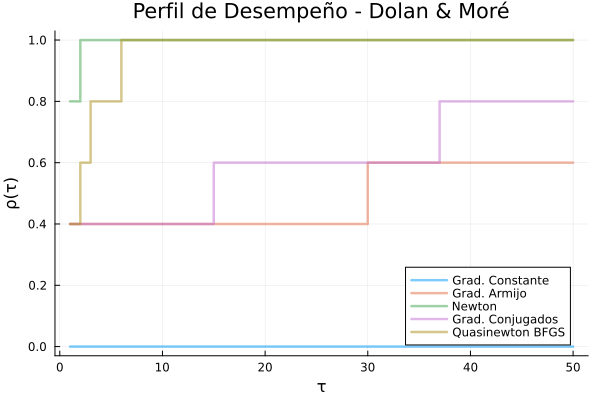

In [41]:
plot(τ_grid,  ρ[1,:], label="Grad. Constante",  lw=2.5, seriestype=:steppost, alpha=0.5)
plot!(τ_grid, ρ[2,:], label="Grad. Armijo",     lw=2.5, seriestype=:steppost, alpha=0.5)
plot!(τ_grid, ρ[3,:], label="Newton",           lw=2.5, seriestype=:steppost, alpha=0.5)
plot!(τ_grid, ρ[4,:], label="Grad. Conjugados", lw=2.5, seriestype=:steppost, alpha=0.5)
plot!(τ_grid, ρ[5,:], label="Quasinewton BFGS", lw=2.5, seriestype=:steppost, alpha=0.5)
plot!(
    legend=:bottomright,
    xlabel="τ",
    ylabel="ρ(τ)",
    yticks=[0, 0.2, 0.4, 0.6, 0.8, 1],
    title="Perfil de Desempeño - Dolan & Moré"
    
)

## **Análisis final**

Si bien el conjunto de funciones objetivo es reducido, el Perfil de Desempeño de Dolan & Moré permite identificar diferencias claras en el rendimiento de los algoritmos. Ordenando los métodos del peor al mejor según convergencia y cantidad de iteraciones:

    5. Gradiente con paso constante
    4. Gradiente con búsqueda lineal (Armijo)
    3. Gradientes Conjugados (Fletcher-Reeves)
    2. Quasi-Newton BFGS
    1. Newton modificado

El gradiente con paso constante es el método más limitado: solo convergió en una función (Rastrigin) y con una cantidad de iteraciones considerablemente mayor que el resto. Su sensibilidad al tamaño de paso fijo lo hace imprácticamente dependiente de una buena elección de $\eta$.

El gradiente con búsqueda lineal y los gradientes conjugados se ubican en un nivel intermedio. Si bien el segundo tuvo un rendimiento un poco mejor, la diferencia no es significativa: convergieron en las mismas funciones y con una cantidad de iteraciones de orden similar.

Los métodos Quasi-Newton BFGS y Newton modificado son, sin lugar a dudas, los de mejor desempeño. Fueron los únicos que convergieron en las cinco funciones objetivo. Newton exhibió su característica convergencia cuadrática, alcanzando el criterio de parada en muy pocas iteraciones. BFGS, sin requerir el cálculo del Hessiano, logró resultados comparables aunque con más iteraciones.

Cabe destacar que tanto Newton como el gradiente con paso constante convergieron a un mínimo local en Rastrigin, distinto del mínimo global propuesto en $x^* = (0, 0)$

In [42]:
println("Mínimo global: f([0,0]) = ", rastrigin([0,0]))
println("Mínimo encontrado por Newton: f([0.994959, 0.994959]) = ", rastrigin([0.994959, 0.994959]))

Mínimo global: f([0,0]) = 0.0
Mínimo encontrado por Newton: f([0.994959, 0.994959]) = 1.9899181142386553


Esto muestra una limitación fundamental del Perfil de Desempeño de Dolan & Moré: la métrica mide exclusivamente eficiencia computacional (iteraciones hasta convergencia) sin considerar la calidad de la solución encontrada. Un análisis más completo debería incorporar un criterio de correctitud, por ejemplo la distancia a un punto $x^*$ propuesto.

En conclusión, las diferencias entre convergencias lineal, superlineal y cuadrática se hacen evidentes en el perfil obtenido. Sin embargo, los resultados resaltan que velocidad de convergencia y calidad de solución son objetivos independientes que un análisis de desempeño completo debería evaluar en conjunto.